# Lab 6 — Segment the Customers
**SDA-AIE-111 · Day 4 · Hour 3 · 50 minutes · pairs**

**Objective.** Deliver a named, profiled, null-tested customer segmentation with a PCA segment map; validate segments *externally* by churn-rate spread; add `segment` as a churn-model feature and measure the effect honestly.

**The module's conscience:** k-means always returns k clusters — even on pure noise. Every claim below must survive the null test.


In [1]:
# --- Course setup (identical in every lab) -----------------------------------
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

def find_repo_root() -> Path:
    """Locate the course repo root by looking for data/manafeth_customers.parquet."""
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "data" / "manafeth_customers.parquet").exists():
            return cand
    raise FileNotFoundError(
        "Course data not found — copy the Manafeth data package files into <repo>/data/")

ROOT = find_repo_root()
DATA = ROOT / "data"
sys.path.insert(0, str(ROOT / "src"))
print("repo root:", ROOT)

repo root: /home/claude/amlf/repo


In [2]:
from sklearn.model_selection import train_test_split
from manafeth.features import (build_preprocessor, build_feature_table,
                               MODEL_NUM_COLS, CAT_COLS, LEAKY)
from manafeth.evaluation import CV, evaluate, recall_at_budget, precision_at_budget

customers = pd.read_parquet(DATA / "manafeth_customers.parquet")
orders = pd.read_parquet(DATA / "manafeth_orders.parquet")
full = build_feature_table(customers, orders, pd.Timestamp("2025-11-01"))

X_all = full.drop(columns=["churned_30d", "customer_id", *LEAKY])
y_all = full["churned_30d"]
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=RANDOM_STATE)
print("train:", X_train.shape, "| churn:", round(y_train.mean(), 3))

train: (38400, 22) | churn: 0.14


## Task 1 — Scale, restart, choose k three ways *(10 min)*

Money features have a savage right tail (bulk-order households) — log them **before** scaling, or one axis owns every distance.


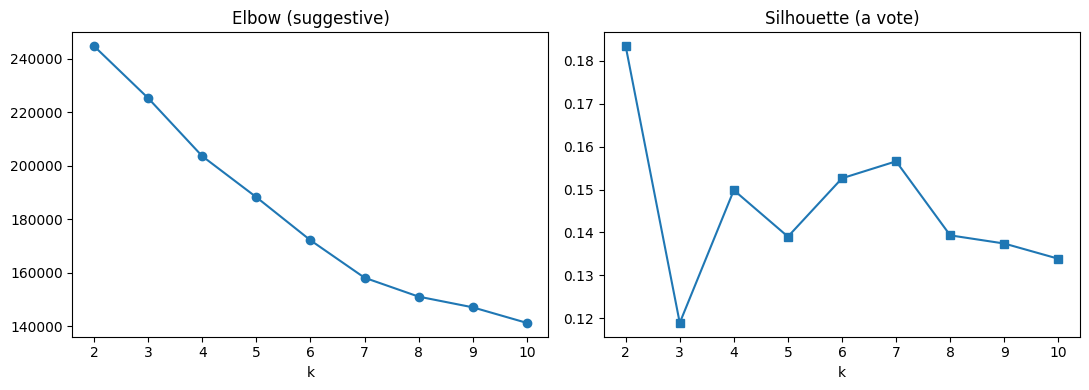

{2: 0.183, 3: 0.119, 4: 0.15, 5: 0.139, 6: 0.153, 7: 0.157, 8: 0.139, 9: 0.137, 10: 0.134}
Neither criterion shouts. Business readability casts the deciding vote in Task 2 —
we profile k=5 and check every segment is nameable.


In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

SEG_COLS = ["orders_per_month", "avg_basket_sar", "days_since_last_order",
            "tenure_months", "distinct_categories", "promo_usage_rate",
            "ramadan_order_share", "weekend_order_share"]

seg_data = X_train[SEG_COLS].copy()
seg_data["avg_basket_sar"] = np.log1p(seg_data["avg_basket_sar"])   # tame the tail FIRST
Z = StandardScaler().fit_transform(seg_data)

inertias, silhouettes = {}, {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init="auto", random_state=RANDOM_STATE).fit(Z)
    inertias[k] = km.inertia_
    silhouettes[k] = silhouette_score(Z, km.labels_, sample_size=10_000,
                                      random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(inertias), list(inertias.values()), marker="o")
axes[0].set_title("Elbow (suggestive)"); axes[0].set_xlabel("k")
axes[1].plot(list(silhouettes), list(silhouettes.values()), marker="s")
axes[1].set_title("Silhouette (a vote)"); axes[1].set_xlabel("k")
plt.tight_layout(); plt.show()
print({k: round(v, 3) for k, v in silhouettes.items()})
print("Neither criterion shouts. Business readability casts the deciding vote in Task 2 —")
print("we profile k=5 and check every segment is nameable.")

## Task 2 — Profile and name *(10 min)*

A segment nobody can name is a segment nobody will use. Name every segment in ≤ 3 words; an unnameable segment is a finding (revisit k), not a failure.


In [4]:
km = KMeans(n_clusters=5, n_init="auto", random_state=RANDOM_STATE).fit(Z)
seg = X_train[SEG_COLS].assign(segment=km.labels_, churned=y_train.values)

profile = seg.groupby("segment").agg(
    size=("segment", "size"),
    orders_pm=("orders_per_month", "mean"),
    basket=("avg_basket_sar", "mean"),
    recency=("days_since_last_order", "mean"),
    ramadan_share=("ramadan_order_share", "mean"),
    weekend_share=("weekend_order_share", "mean"),
    churn_rate=("churned", "mean"),
).round(2)
print(profile.sort_values("churn_rate").to_string())
print("\nName each segment in <= 3 words (e.g. 'daily essentials loyalists',")
print("'weekly family shoppers', 'seasonal bargain hunters', 'drifting newcomers', ...)")
print("The churn-rate spread across segments is the external-usefulness evidence.")

          size  orders_pm  basket  recency  ramadan_share  weekend_share  churn_rate
segment                                                                             
1         5283       6.39  163.30     4.90           0.08           0.28        0.03
0        13784       2.90  106.22    10.37           0.04           0.30        0.06
3         4752       2.34   87.28    13.41           0.29           0.29        0.13
2        11167       1.60   63.35    13.14           0.02           0.23        0.20
4         3414       1.58   66.73    57.49           0.05           0.28        0.45

Name each segment in <= 3 words (e.g. 'daily essentials loyalists',
'weekly family shoppers', 'seasonal bargain hunters', 'drifting newcomers', ...)
The churn-rate spread across segments is the external-usefulness evidence.


## Task 3 — PCA: budget sheet, map, loadings *(10 min)*

Compress, view, interpret — in that order. The 2-D map is a *view*, not proof.


PC1+PC2 carry: 0.47 of the variance — what the 2-D map shows (and hides)
components for 95%: 7 of 8


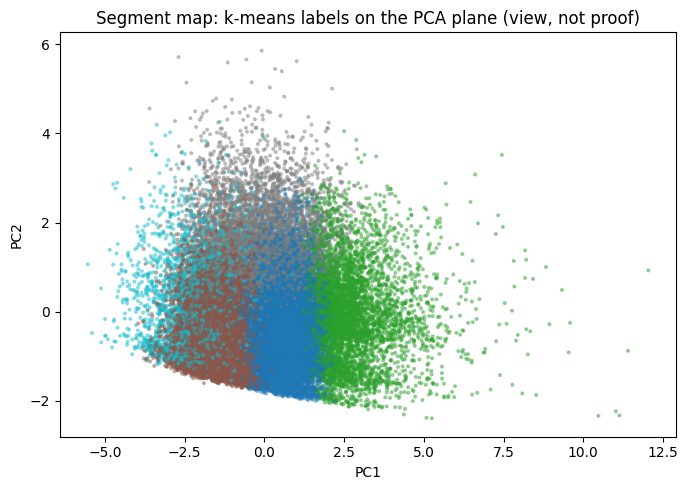

                        PC1   PC2
days_since_last_order -0.32  0.10
promo_usage_rate      -0.30  0.10
weekend_order_share    0.04  0.32
ramadan_order_share    0.09  0.66
tenure_months          0.12  0.66
avg_basket_sar         0.49 -0.06
orders_per_month       0.52 -0.05
distinct_categories    0.53 -0.06

Write one-line readings: PC1 = ...axis; PC2 = ...axis


In [5]:
from sklearn.decomposition import PCA

pca = PCA(random_state=RANDOM_STATE).fit(Z)
cum = np.cumsum(pca.explained_variance_ratio_)
print("PC1+PC2 carry:", round(cum[1], 2), "of the variance — what the 2-D map shows (and hides)")
print("components for 95%:", int(np.searchsorted(cum, 0.95) + 1), "of", Z.shape[1])

coords = pca.transform(Z)[:, :2]
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(coords[:, 0], coords[:, 1], c=km.labels_, s=4, alpha=0.4, cmap="tab10")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Segment map: k-means labels on the PCA plane (view, not proof)")
plt.tight_layout(); plt.show()

loadings = pd.DataFrame(pca.components_[:2].T, index=SEG_COLS, columns=["PC1", "PC2"])
print(loadings.round(2).sort_values("PC1").to_string())
print("\nWrite one-line readings: PC1 = ...axis; PC2 = ...axis")

## Task 4 — The null test *(5 min)*

Would we have "found" structure in pure noise? Report both numbers; the gap IS the claim.


In [6]:
rng = np.random.default_rng(RANDOM_STATE)
noise = rng.standard_normal(Z.shape)

km_noise = KMeans(n_clusters=5, n_init="auto", random_state=RANDOM_STATE).fit(noise)
sil_real = silhouette_score(Z, km.labels_, sample_size=10_000, random_state=RANDOM_STATE)
sil_noise = silhouette_score(noise, km_noise.labels_, sample_size=10_000,
                             random_state=RANDOM_STATE)
print(f"silhouette (real data): {sil_real:.3f}")
print(f"silhouette (noise):     {sil_noise:.3f}")
print("Our structure clears the null — but note the honest reading: Manafeth behaviour")
print("is largely a continuum; the segments are a useful quantisation, not natural kinds.")

silhouette (real data): 0.139
silhouette (noise):     0.073
Our structure clears the null — but note the honest reading: Manafeth behaviour
is largely a continuum; the segments are a useful quantisation, not natural kinds.


## Task 5 — External usefulness: segment as a feature *(10 min)*

The churn-rate spread already validated the segments externally. Now the harder test: does `segment` help the supervised champion?


In [7]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Assign segments to ALL rows through the same (fitted) scaler + kmeans
seg_all = X_train[SEG_COLS].copy()
seg_all["avg_basket_sar"] = np.log1p(seg_all["avg_basket_sar"])
X_aug = X_train.assign(segment=km.predict(
    StandardScaler().fit(seg_data).transform(seg_all)).astype(str))

champion = Pipeline([
    ("prep", build_preprocessor(MODEL_NUM_COLS, CAT_COLS + ["segment"])),
    ("clf", XGBClassifier(n_estimators=340, learning_rate=0.05, max_depth=4,
                          subsample=0.8, colsample_bytree=0.8, scale_pos_weight=6.1,
                          eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1)),
])
res = evaluate(champion, X_aug, y_train, "xgb+segment")
print(res[["pr_auc_mean", "pr_auc_std"]])
print("\nIf the delta vs Lab 5 is ~zero: expected, and worth saying aloud — the segments")
print("were built FROM the same features the model already sees. Their value is the")
print("shared language they give the CRM team, not extra PR-AUC.")

pr_auc_mean    0.577
pr_auc_std     0.007
Name: xgb+segment, dtype: float64

If the delta vs Lab 5 is ~zero: expected, and worth saying aloud — the segments
were built FROM the same features the model already sees. Their value is the
shared language they give the CRM team, not extra PR-AUC.


**Commit:** `feat(lab6): named segments, null-tested, churn-validated`
